In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# Suppress warnings for clean presentation
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Ensure working directory is project root
current_path = Path.cwd()
if current_path.name == 'notebook':
    os.chdir(current_path.parent)

data_dir = Path('data/raw')

print(f"Active working directory: {Path.cwd()}")
print(f"Data directory: {data_dir.resolve()} (Exists: {data_dir.exists()})")

Active working directory: d:\school\Perkuliahan\Semester_5\MLOps
Data directory: D:\school\Perkuliahan\Semester_5\MLOps\data\raw (Exists: True)


In [3]:
# Load column definitions from features CSV
features_file = data_dir / 'NUSW-NB15_features.csv'
features_df = pd.read_csv(features_file, encoding='latin1')

# Strip whitespace from column names to avoid formatting issues (e.g., 'ct_src_ ltm')
features = [str(name).strip() for name in features_df['Name']]
print(f"Total features defined in metadata: {len(features)}")
print("First 10 features:", features[:10])
print("Last 5 features: ", features[-5:])

Total features defined in metadata: 49
First 10 features: ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl']
Last 5 features:  ['ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label']


In [4]:
# Define explicit dtypes for columns known to contain mixed/string values
# to avoid pandas DtypeWarning and optimize memory usage
dtype_spec = {
    'sport': str,
    'dsport': str,
    'ct_ftp_cmd': str,
    'attack_cat': str,
    'Label': np.int64
}

print("Loading UNSW-NB15 dataset splits (df1 - df4)...")
df1 = pd.read_csv(data_dir / 'UNSW-NB15_1.csv', names=features, dtype=dtype_spec, low_memory=False)
df2 = pd.read_csv(data_dir / 'UNSW-NB15_2.csv', names=features, dtype=dtype_spec, low_memory=False)
df3 = pd.read_csv(data_dir / 'UNSW-NB15_3.csv', names=features, dtype=dtype_spec, low_memory=False)
df4 = pd.read_csv(data_dir / 'UNSW-NB15_4.csv', names=features, dtype=dtype_spec, low_memory=False)

dfs = {'df1': df1, 'df2': df2, 'df3': df3, 'df4': df4}
print("All 4 dataframes loaded successfully.")

Loading UNSW-NB15 dataset splits (df1 - df4)...
All 4 dataframes loaded successfully.


---
## 1. 🔍 Cross-Dataframe Comparison (`df1`, `df2`, `df3`, `df4`)

In the UNSW-NB15 dataset, the traffic flows were captured sequentially and split into multiple files. In an MLOps continual learning architecture, these sequential splits serve as an ideal simulation of **incoming data batches over time** (e.g., Week 1, Week 2, Week 3, Week 4).

Here we compare the structure, quality, class distribution, and data drift across all 4 dataframes.

In [5]:
# 1.1 Dimension, Volume & Memory Footprint Comparison
summary_records = []

for name, df in dfs.items():
    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    total_rows = len(df)
    total_cols = df.shape[1]
    attack_count = (df['Label'] == 1).sum()
    normal_count = (df['Label'] == 0).sum()
    attack_pct = (attack_count / total_rows) * 100
    missing_cells = df.isna().sum().sum()
    
    summary_records.append({
        'Dataset': name,
        'Rows': f"{total_rows:,}",
        'Columns': total_cols,
        'Memory (MB)': f"{mem_mb:.2f}",
        'Normal Flows': f"{normal_count:,}",
        'Attack Flows': f"{attack_count:,}",
        'Attack Ratio (%)': f"{attack_pct:.2f}%",
        'Total Missing Cells': f"{missing_cells:,}"
    })

summary_df = pd.DataFrame(summary_records)
display(summary_df)

# Total combined dataset size
total_rows_all = sum(len(df) for df in dfs.values())
print(f"Total Combined Flows across all splits: {total_rows_all:,} rows")

,Dataset,Rows,Columns,Memory (MB),Normal Flows,Attack Flows,Attack Ratio (%),Total Missing Cells
0,df1,"700,001",49,567.13,"677,786","22,215",3.17%,"677,786"
1,df2,"700,001",49,568.27,"647,252","52,749",7.54%,"1,239,546"
2,df3,"700,001",49,571.87,"542,576","157,425",22.49%,"1,888,410"
3,df4,"440,044",49,359.15,"351,150","88,894",20.20%,"1,191,046"


Total Combined Flows across all splits: 2,540,047 rows


In [6]:
# 1.2 Inspect Schema Consistency and Mixed Data Types
print("--- Investigating Columns with Inconsistent / Mixed Data Types ---")

# Sport & Dsport non-numeric exploration (e.g., hexadecimal ports like 0x000b or hyphen '-')
for port_col in ['sport', 'dsport']:
    for name, df in dfs.items():
        non_numeric = df[~df[port_col].astype(str).str.isnumeric()][port_col].dropna().unique()
        if len(non_numeric) > 0:
            print(f"[{name}] {port_col} sample non-numeric values (first 5): {non_numeric[:5]}")

# ct_ftp_cmd sample values
print("\nSample unique values in ct_ftp_cmd across splits:")
for name, df in dfs.items():
    vals = df['ct_ftp_cmd'].dropna().unique()[:6]
    print(f"[{name}] ct_ftp_cmd samples: {vals}")

--- Investigating Columns with Inconsistent / Mixed Data Types ---
[df1] sport sample non-numeric values (first 5): <StringArray>
['0x000b', '0x000c', '-']
Length: 3, dtype: str
[df1] dsport sample non-numeric values (first 5): <StringArray>
['0xc0a8', '-', '0x20205321']
Length: 3, dtype: str
[df2] dsport sample non-numeric values (first 5): <StringArray>
['0xcc09']
Length: 1, dtype: str
[df3] dsport sample non-numeric values (first 5): <StringArray>
['0xcc09']
Length: 1, dtype: str
[df4] dsport sample non-numeric values (first 5): <StringArray>
['0xcc09']
Length: 1, dtype: str

Sample unique values in ct_ftp_cmd across splits:
[df1] ct_ftp_cmd samples: <StringArray>
['0', '1', '6', '2', '4', '8']
Length: 6, dtype: str
[df2] ct_ftp_cmd samples: <StringArray>
['0', '1', '4', '2', ' ']
Length: 5, dtype: str
[df3] ct_ftp_cmd samples: <StringArray>
[' ', '1', '4', '2']
Length: 4, dtype: str
[df4] ct_ftp_cmd samples: <StringArray>
[' ', '1', '4', '2']
Length: 4, dtype: str


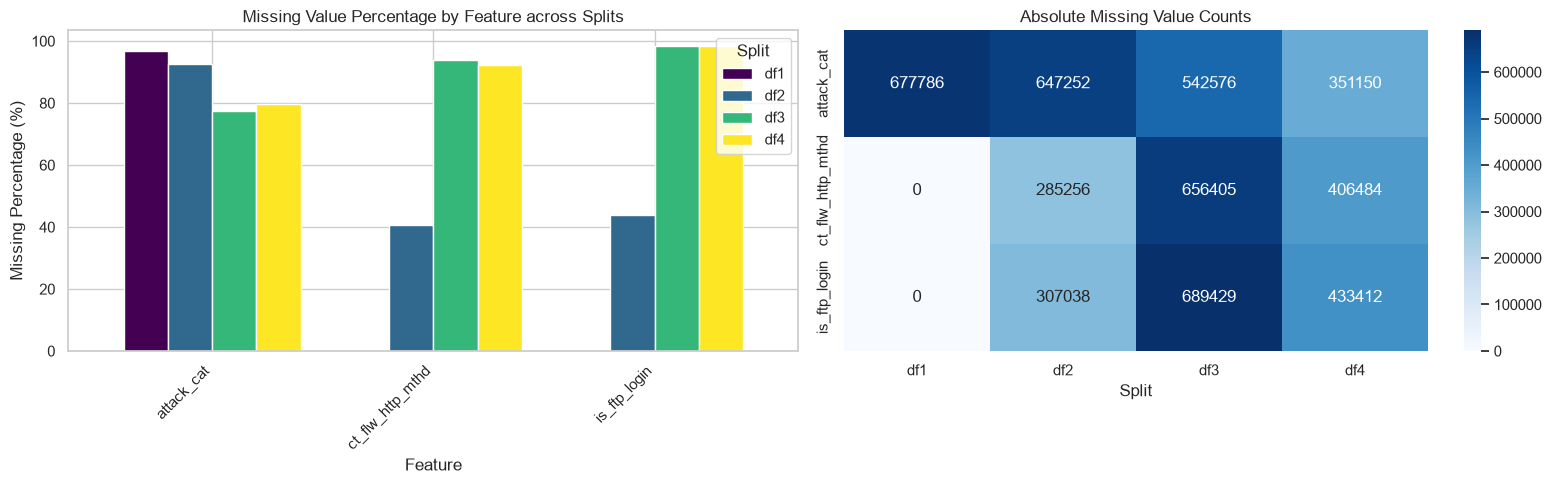

Key observation: 'attack_cat' is NaN for benign (normal) traffic flows.
'ct_flw_http_mthd' and 'is_ftp_login' have high null percentages because most flows are not HTTP/FTP.


In [7]:
# 1.3 Missing Values Comparison Across Splits
missing_data = []

for name, df in dfs.items():
    null_counts = df.isna().sum()
    null_cols = null_counts[null_counts > 0]
    for col, count in null_cols.items():
        missing_data.append({
            'Split': name,
            'Feature': col,
            'Null Count': count,
            'Null Percentage': (count / len(df)) * 100
        })

missing_df = pd.DataFrame(missing_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pivot for heatmap and grouped bar
if not missing_df.empty:
    pivot_missing = missing_df.pivot(index='Feature', columns='Split', values='Null Percentage').fillna(0)
    
    # Bar plot of missing percentages
    pivot_missing.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.8)
    axes[0].set_title('Missing Value Percentage by Feature across Splits')
    axes[0].set_ylabel('Missing Percentage (%)')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    axes[0].legend(title='Split')
    
    # Heatmap of null counts
    pivot_counts = missing_df.pivot(index='Feature', columns='Split', values='Null Count').fillna(0)
    sns.heatmap(pivot_counts, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
    axes[1].set_title('Absolute Missing Value Counts')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Key observation: 'attack_cat' is NaN for benign (normal) traffic flows.")
print("'ct_flw_http_mthd' and 'is_ftp_login' have high null percentages because most flows are not HTTP/FTP.")

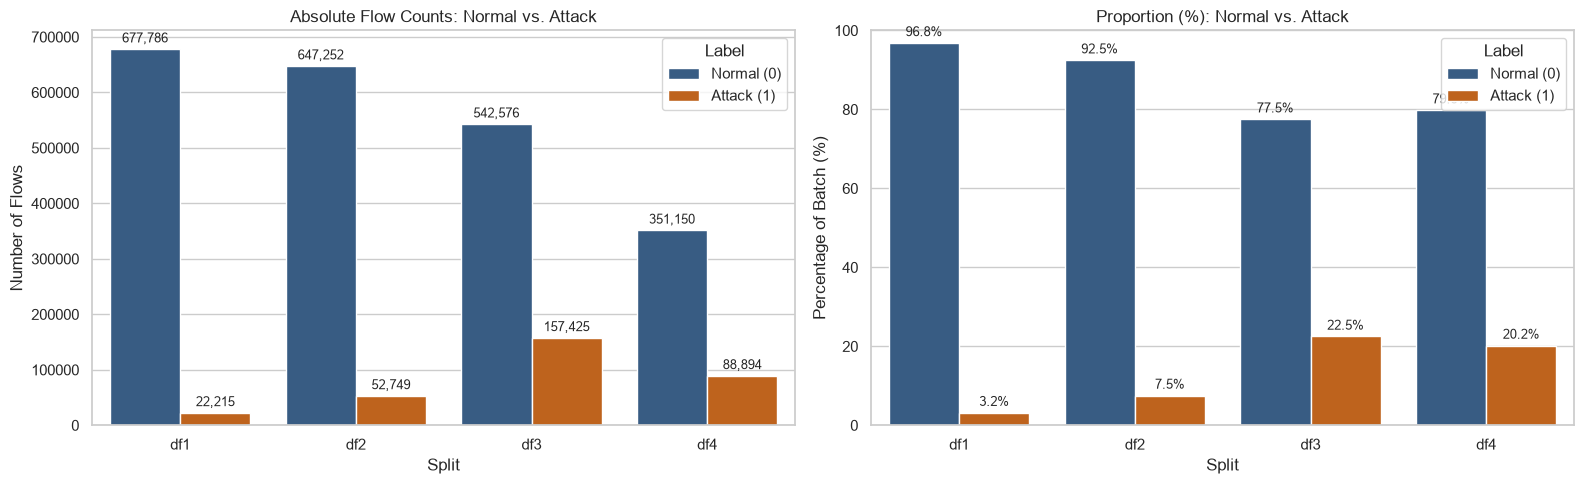

Count            Percentage           
Label Attack (1) Normal (0) Attack (1) Normal (0)
Split                                            
df1      22215.0   677786.0   3.173567  96.826433
df2      52749.0   647252.0   7.535561  92.464439
df3     157425.0   542576.0  22.489254  77.510746
df4      88894.0   351150.0  20.201162  79.798838

In [8]:
# 1.4 Binary Target Label (Normal vs. Attack) Across Splits
label_data = []

for name, df in dfs.items():
    counts = df['Label'].value_counts()
    norm_counts = df['Label'].value_counts(normalize=True) * 100
    for label_val in [0, 1]:
        label_data.append({
            'Split': name,
            'Label': 'Normal (0)' if label_val == 0 else 'Attack (1)',
            'Count': counts.get(label_val, 0),
            'Percentage': norm_counts.get(label_val, 0.0)
        })

label_df = pd.DataFrame(label_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts bar plot
sns.barplot(data=label_df, x='Split', y='Count', hue='Label', ax=axes[0], palette=['#2b5c8f', '#d95f02'])
axes[0].set_title('Absolute Flow Counts: Normal vs. Attack')
axes[0].set_ylabel('Number of Flows')

# Percentage bar plot
sns.barplot(data=label_df, x='Split', y='Percentage', hue='Label', ax=axes[1], palette=['#2b5c8f', '#d95f02'])
axes[1].set_title('Proportion (%): Normal vs. Attack')
axes[1].set_ylabel('Percentage of Batch (%)')
axes[1].set_ylim(0, 100)

for ax in axes:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:,.0f}' if ax == axes[0] else f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                        textcoords='offset points')

plt.tight_layout()
plt.show()

display(label_df.pivot(index='Split', columns='Label', values=['Count', 'Percentage']))

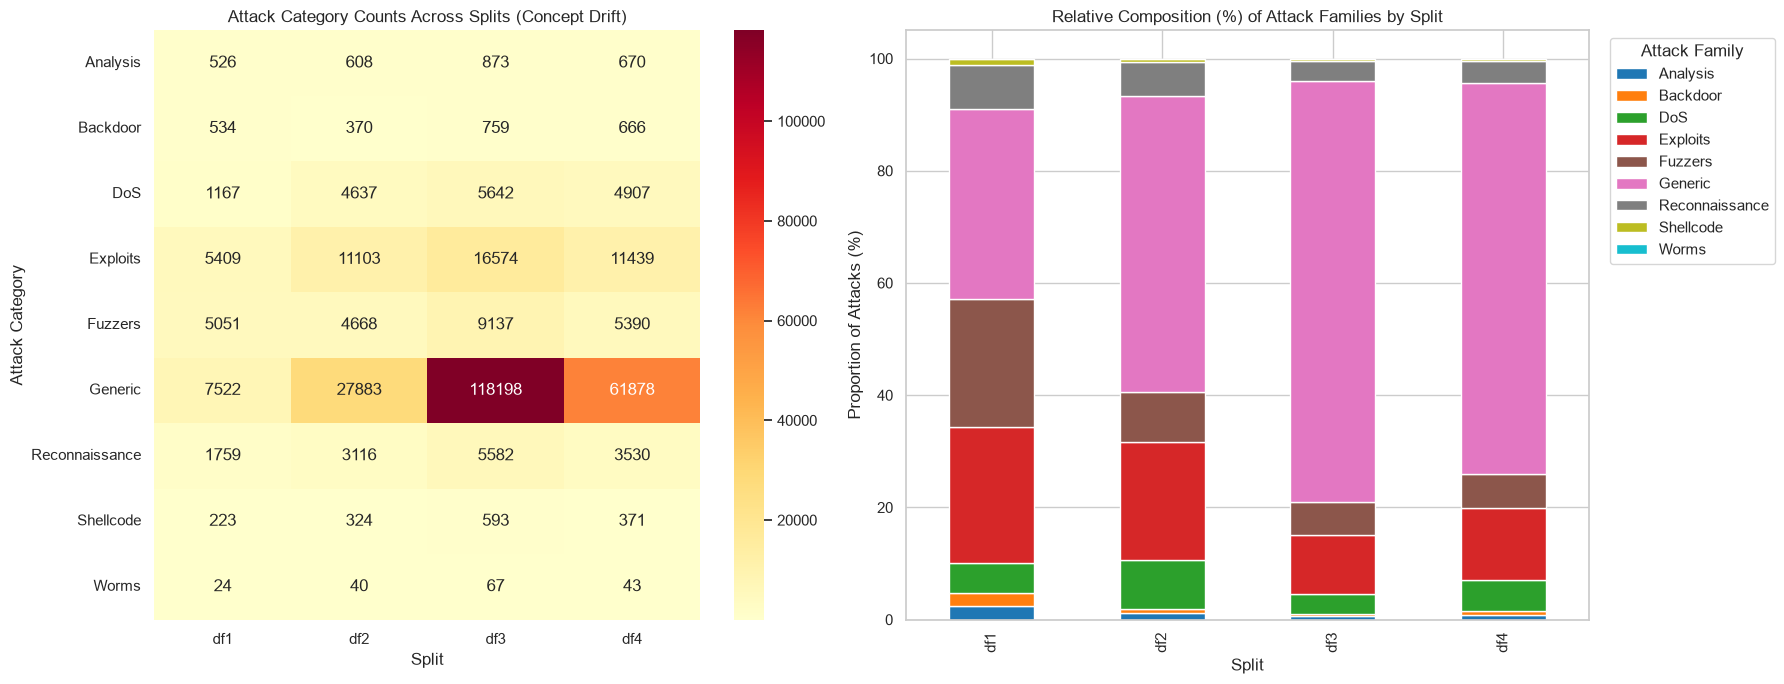

Key MLOps Insight: The relative proportion of attack types fluctuates dramatically across splits.
For example, Generic and Exploits dominate certain splits, while Worms and Shellcode are rare anomalies.


In [9]:
# 1.5 Attack Categories (attack_cat) Across Splits: Visualizing Concept Drift
attack_records = []

for name, df in dfs.items():
    # Clean whitespace and standardize casing
    cleaned_cat = df['attack_cat'].fillna('Normal').astype(str).str.strip()
    # Normalize variants (e.g. 'Backdoor' vs 'Backdoors')
    cleaned_cat = cleaned_cat.replace({'Backdoors': 'Backdoor'})
    
    cat_counts = cleaned_cat.value_counts()
    for cat, count in cat_counts.items():
        attack_records.append({
            'Split': name,
            'Attack_Category': cat,
            'Count': count
        })

attack_cat_df = pd.DataFrame(attack_records)
pivot_attack_cat = attack_cat_df.pivot(index='Attack_Category', columns='Split', values='Count').fillna(0)

# Filter out 'Normal' to focus on attack families
attack_only_pivot = pivot_attack_cat.drop('Normal', errors='ignore')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap of attack counts
sns.heatmap(attack_only_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Attack Category Counts Across Splits (Concept Drift)')
axes[0].set_ylabel('Attack Category')

# Normalized percentage distribution of attack types per split
attack_only_pct = attack_only_pivot.div(attack_only_pivot.sum(axis=0), axis=1) * 100
attack_only_pct.T.plot(kind='bar', stacked=True, colormap='tab10', ax=axes[1])
axes[1].set_title('Relative Composition (%) of Attack Families by Split')
axes[1].set_ylabel('Proportion of Attacks (%)')
axes[1].set_xlabel('Split')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Attack Family')

plt.tight_layout()
plt.show()

print("Key MLOps Insight: The relative proportion of attack types fluctuates dramatically across splits.")
print("For example, Generic and Exploits dominate certain splits, while Worms and Shellcode are rare anomalies.")

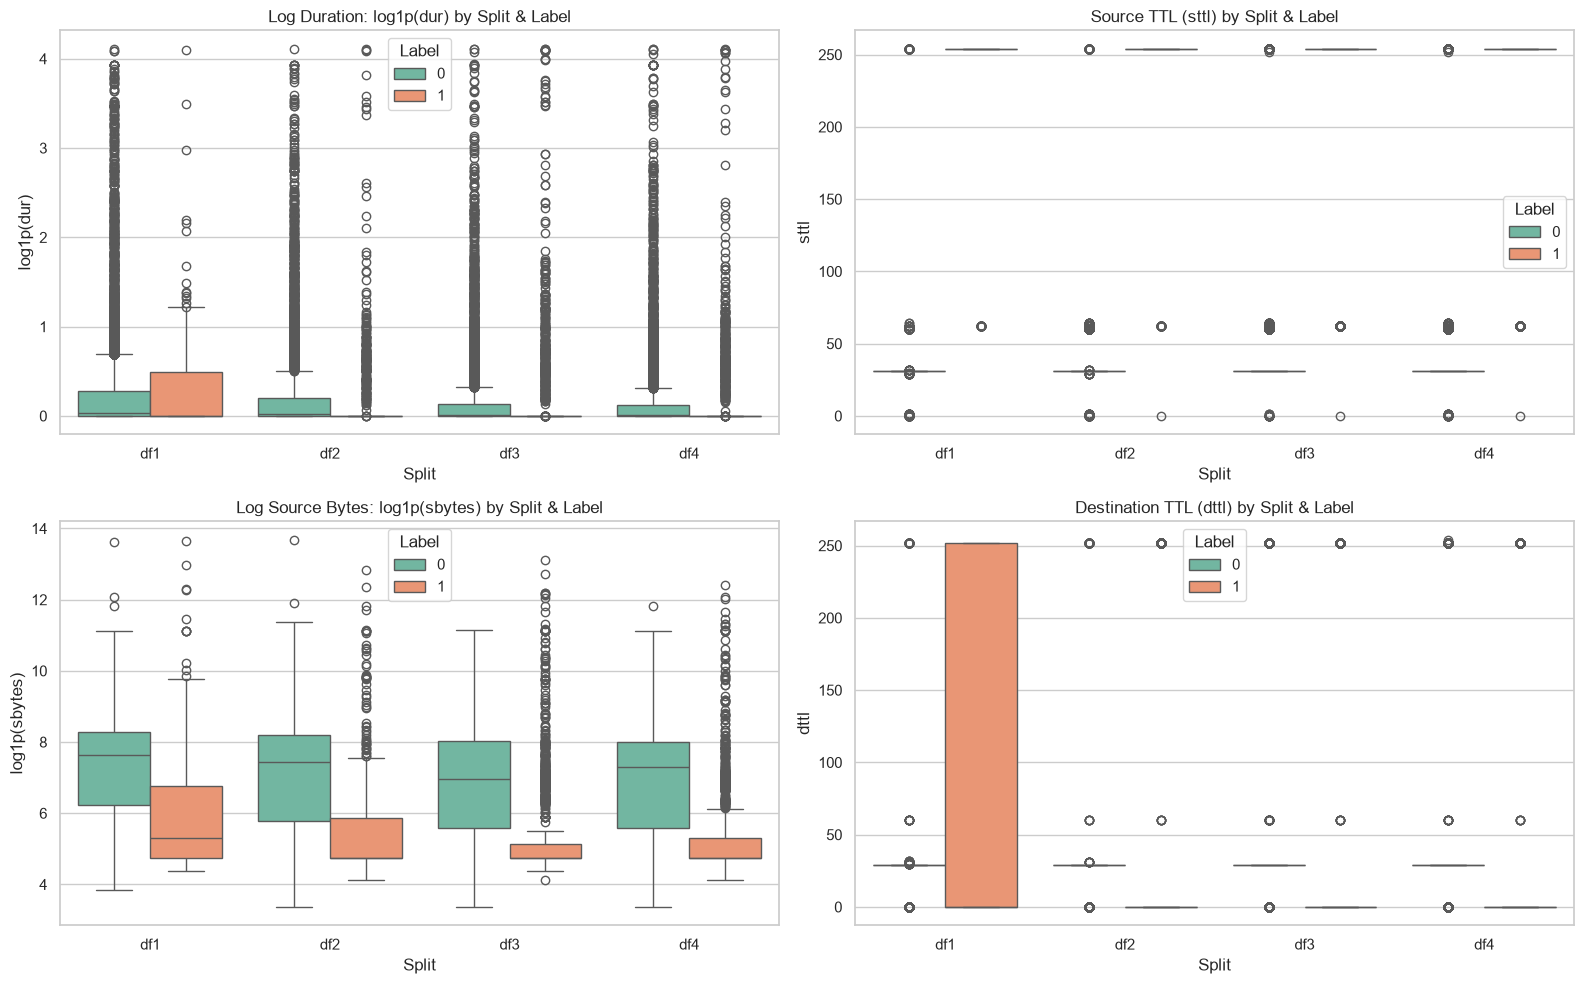

--- Mean Values of Key Features Across Splits ---


,dur,sbytes,dbytes,Sload,Dload,sttl
Split,,,,,,
df1,0.754425,4769.2141,46999.7967,6.689928e+06,2.955523e+06,39.1465
df2,0.535968,3968.7407,36510.5037,2.076020e+07,2.740031e+06,50.2146
df3,0.547590,3250.8179,28624.7763,6.642532e+07,1.940831e+06,88.2534
df4,0.528894,2992.2028,26792.5555,6.747756e+07,1.913356e+06,81.8548


In [10]:
# 1.6 Feature Distribution Drift across Splits
# Sample 10,000 flows from each split for fast, memory-safe comparative plotting
sampled_dfs = []
for name, df in dfs.items():
    sample = df[['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'sttl', 'dttl', 'Label']].sample(
        n=min(10000, len(df)), random_state=42
    ).copy()
    sample['Split'] = name
    sampled_dfs.append(sample)

combined_sample = pd.concat(sampled_dfs, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Log duration (dur)
combined_sample['log_dur'] = np.log1p(np.maximum(combined_sample['dur'], 0))
sns.boxplot(data=combined_sample, x='Split', y='log_dur', hue='Label', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Log Duration: log1p(dur) by Split & Label')
axes[0, 0].set_ylabel('log1p(dur)')

# 2. Source TTL (sttl)
sns.boxplot(data=combined_sample, x='Split', y='sttl', hue='Label', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Source TTL (sttl) by Split & Label')
axes[0, 1].set_ylabel('sttl')

# 3. Log Source Bytes (sbytes)
combined_sample['log_sbytes'] = np.log1p(combined_sample['sbytes'])
sns.boxplot(data=combined_sample, x='Split', y='log_sbytes', hue='Label', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Log Source Bytes: log1p(sbytes) by Split & Label')
axes[1, 0].set_ylabel('log1p(sbytes)')

# 4. Destination TTL (dttl)
sns.boxplot(data=combined_sample, x='Split', y='dttl', hue='Label', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Destination TTL (dttl) by Split & Label')
axes[1, 1].set_ylabel('dttl')

plt.tight_layout()
plt.show()

# Quantitative comparison of means across splits
print("--- Mean Values of Key Features Across Splits ---")
display(combined_sample.groupby('Split')[['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'sttl']].mean())

---
## 2. 🔬 Dataset Characteristics & Feature Deep Dive

In this section, we analyze the characteristics of the UNSW-NB15 dataset as a whole:
- **Feature taxonomy** and grouping.
- **Categorical flow properties** (`proto`, `state`, `service`).
- **Multicollinearity & Correlation Analysis**.
- **Distribution skewness and scale disparity** in continuous network flow features.

In [11]:
# 2.1 Feature Taxonomy and Grouping
feature_groups = {
    'Network Identifiers': ['srcip', 'sport', 'dstip', 'dsport'],
    'Protocol & State': ['proto', 'state', 'service'],
    'Flow & Packet Metrics': ['dur', 'sbytes', 'dbytes', 'Spkts', 'Dpkts', 'smeansz', 'dmeansz'],
    'TCP Parameters': ['swin', 'dwin', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat'],
    'Jitter & Inter-packet Time': ['Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt'],
    'Content & Service Specific': ['trans_depth', 'res_bdy_len', 'is_sm_ips_ports', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd'],
    'Connection Count Metrics (ct_*)': [col for col in features if col.startswith('ct_') and col not in ['ct_flw_http_mthd', 'ct_ftp_cmd']],
    'Ground Truth Labels': ['attack_cat', 'Label']
}

for group_name, cols in feature_groups.items():
    print(f"● {group_name} ({len(cols)} features):")
    print(f"  {', '.join(cols)}\n")

● Network Identifiers (4 features):
  srcip, sport, dstip, dsport

● Protocol & State (3 features):
  proto, state, service

● Flow & Packet Metrics (7 features):
  dur, sbytes, dbytes, Spkts, Dpkts, smeansz, dmeansz

● TCP Parameters (7 features):
  swin, dwin, stcpb, dtcpb, tcprtt, synack, ackdat

● Jitter & Inter-packet Time (6 features):
  Sjit, Djit, Stime, Ltime, Sintpkt, Dintpkt

● Content & Service Specific (6 features):
  trans_depth, res_bdy_len, is_sm_ips_ports, ct_flw_http_mthd, is_ftp_login, ct_ftp_cmd

● Connection Count Metrics (ct_*) (8 features):
  ct_state_ttl, ct_srv_src, ct_srv_dst, ct_dst_ltm, ct_src_ ltm, ct_src_dport_ltm, ct_dst_sport_ltm, ct_dst_src_ltm

● Ground Truth Labels (2 features):
  attack_cat, Label



In [ ]:
# 2.2 Categorical Features Analysis: proto, state, service
# Using the representative sample to explore relationships with attack label
fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# Top Protocols
top_protos = combined_sample['Split'].map(lambda _: df1['proto']).iloc[:10000].value_counts().head(10).index
proto_data = df1[df1['proto'].isin(top_protos)]
proto_attack_rate = proto_data.groupby('proto')['Label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=proto_attack_rate.index, y=proto_attack_rate.values, ax=axes[0], palette='Blues_r')
axes[0].set_title('Attack Rate (%) by Top 10 Protocols')
axes[0].set_ylabel('Attack Percentage (%)')
axes[0].set_xlabel('Protocol (proto)')

# Top States
top_states = df1['state'].value_counts().head(8).index
state_data = df1[df1['state'].isin(top_states)]
state_attack_rate = state_data.groupby('state')['Label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=state_attack_rate.index, y=state_attack_rate.values, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Attack Rate (%) by Top Connection States')
axes[1].set_ylabel('Attack Percentage (%)')
axes[1].set_xlabel('Connection State (state)')

# Top Services
service_counts = df1['service'].replace('-', 'none').value_counts().head(10)
service_data = df1.copy()
service_data['service_clean'] = service_data['service'].replace('-', 'none')
service_attack_rate = service_data[service_data['service_clean'].isin(service_counts.index)].groupby('service_clean')['Label'].mean().sort_values(ascending=False) * 100
sns.barplot(x=service_attack_rate.index, y=service_attack_rate.values, ax=axes[2], palette='Greens_r')
axes[2].set_title('Attack Rate (%) by Network Service')
axes[2].set_ylabel('Attack Percentage (%)')
axes[2].set_xlabel('Network Service (service)')

plt.tight_layout()
plt.show()

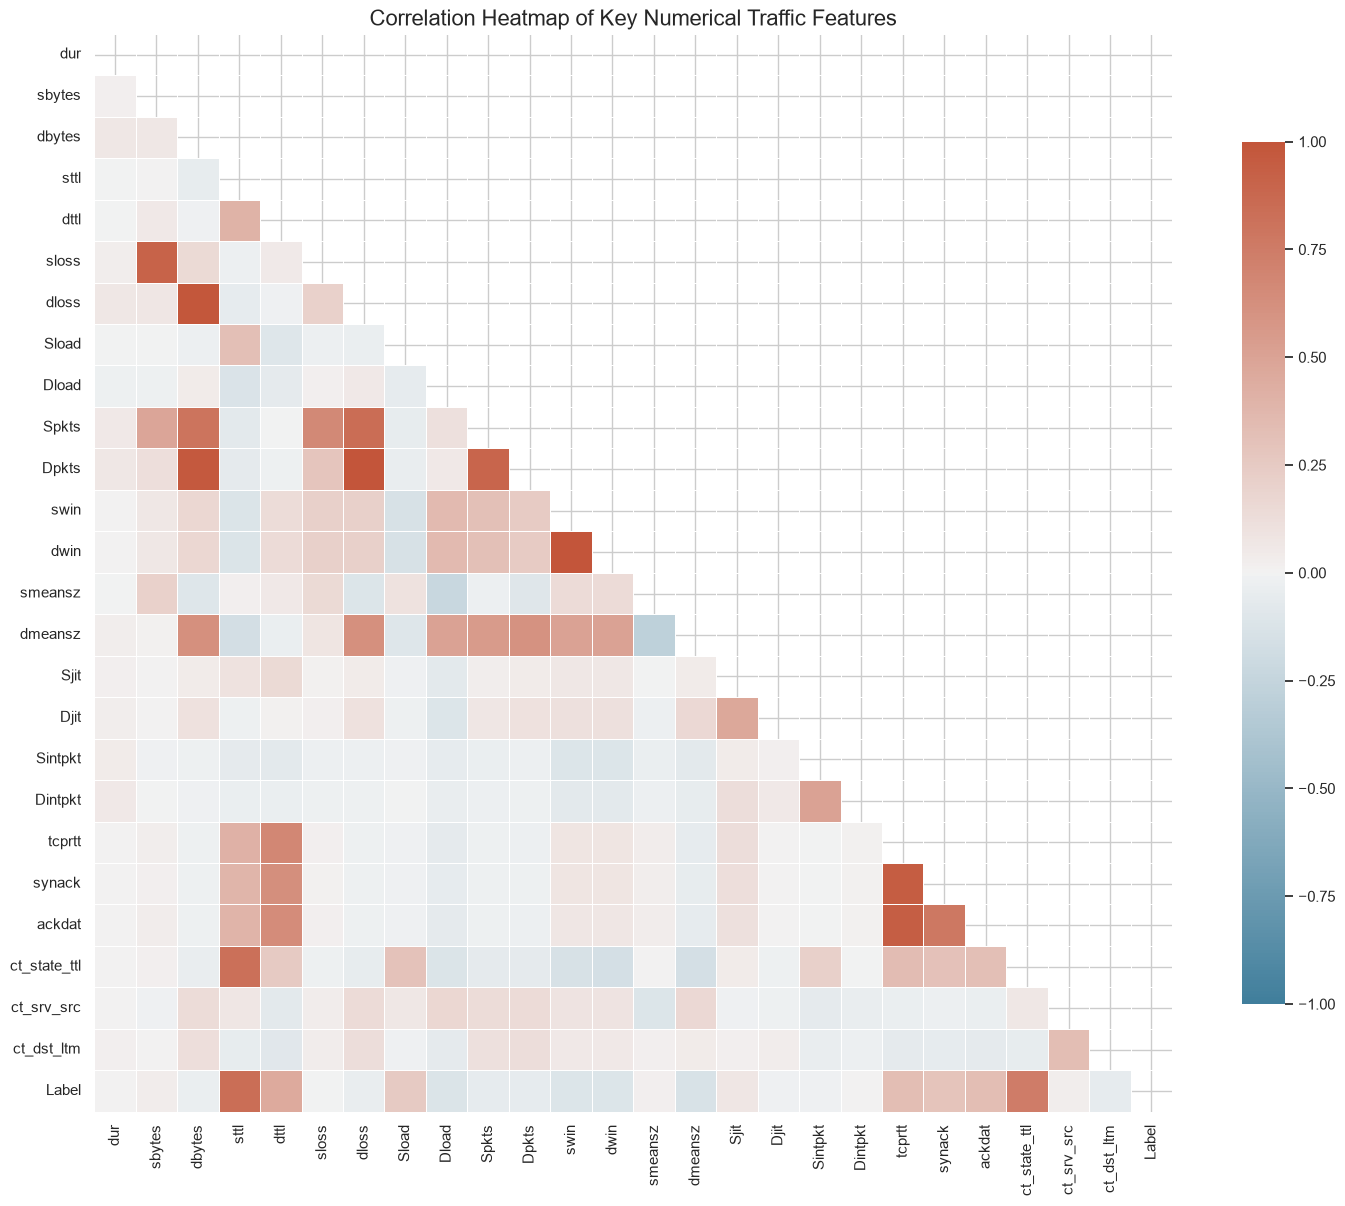

--- Highly Correlated Feature Pairs (|r| >= 0.85) ---


,Feature 1,Feature 2,Correlation (r)
5,dwin,swin,0.9975
3,Dpkts,dloss,0.9929
1,dloss,dbytes,0.9913
2,Dpkts,dbytes,0.9713
6,synack,tcprtt,0.9456
7,ackdat,tcprtt,0.9380
0,sloss,sbytes,0.9110
4,Dpkts,Spkts,0.8924


In [12]:
# 2.3 Multicollinearity and Correlation Analysis
numeric_cols = [
    'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss',
    'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin',
    'smeansz', 'dmeansz', 'Sjit', 'Djit', 'Sintpkt', 'Dintpkt',
    'tcprtt', 'synack', 'ackdat', 'ct_state_ttl', 'ct_srv_src', 'ct_dst_ltm', 'Label'
]

# Calculate correlation matrix on df1 numeric subset
corr_matrix = df1[numeric_cols].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, annot=False
)
plt.title('Correlation Heatmap of Key Numerical Traffic Features', fontsize=16)
plt.show()

# Identify pairs with severe multicollinearity (|r| > 0.85)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.85 and col1 != 'Label' and col2 != 'Label':
            high_corr.append({'Feature 1': col1, 'Feature 2': col2, 'Correlation (r)': round(val, 4)})

high_corr_df = pd.DataFrame(high_corr).sort_values(by='Correlation (r)', ascending=False)
print("--- Highly Correlated Feature Pairs (|r| >= 0.85) ---")
display(high_corr_df)

--- Feature Skewness Coefficients (df1) ---


,Skewness
dur,331.265507
sbytes,183.492421
Djit,98.504915
Sjit,51.924847
Sload,30.340087
dbytes,6.414024
Dload,1.659569


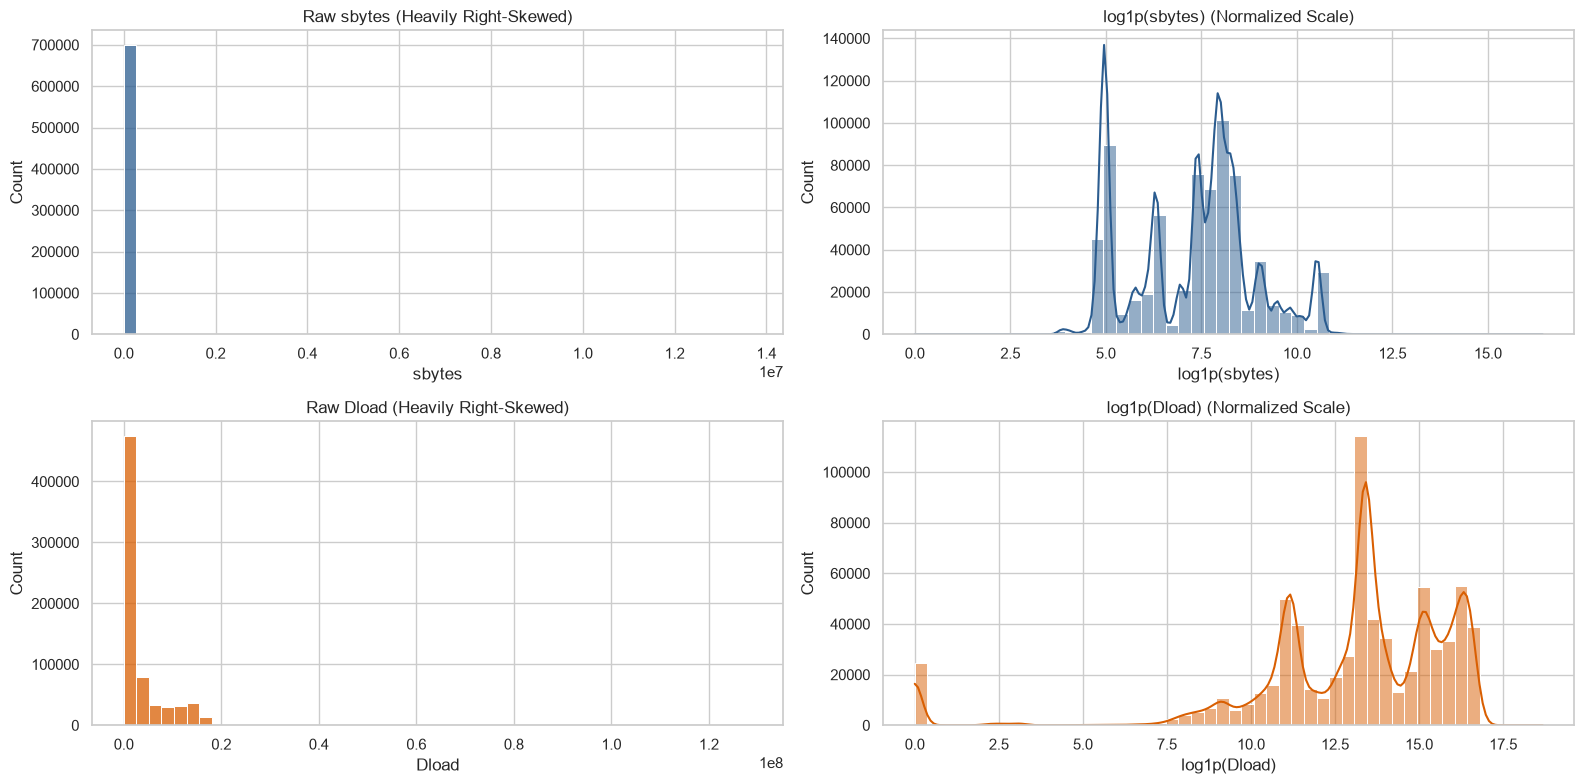

In [13]:
# 2.4 Skewness & Scale Disparity in Continuous Features
skew_cols = ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'Sjit', 'Djit']
skew_sample = df1[skew_cols].apply(pd.to_numeric, errors='coerce').dropna()

skewness_vals = skew_sample.skew().to_frame(name='Skewness').sort_values(by='Skewness', ascending=False)
print("--- Feature Skewness Coefficients (df1) ---")
display(skewness_vals)

# Visualizing before and after log-transformation for heavily skewed flow features
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Raw Sbytes vs Log Sbytes
sns.histplot(skew_sample['sbytes'], bins=50, ax=axes[0, 0], color='#2b5c8f', kde=False)
axes[0, 0].set_title('Raw sbytes (Heavily Right-Skewed)')
axes[0, 0].set_xlabel('sbytes')

sns.histplot(np.log1p(skew_sample['sbytes']), bins=50, ax=axes[0, 1], color='#2b5c8f', kde=True)
axes[0, 1].set_title('log1p(sbytes) (Normalized Scale)')
axes[0, 1].set_xlabel('log1p(sbytes)')

# Raw Dload vs Log Dload
sns.histplot(skew_sample['Dload'], bins=50, ax=axes[1, 0], color='#d95f02', kde=False)
axes[1, 0].set_title('Raw Dload (Heavily Right-Skewed)')
axes[1, 0].set_xlabel('Dload')

sns.histplot(np.log1p(skew_sample['Dload']), bins=50, ax=axes[1, 1], color='#d95f02', kde=True)
axes[1, 1].set_title('log1p(Dload) (Normalized Scale)')
axes[1, 1].set_xlabel('log1p(Dload)')

plt.tight_layout()
plt.show()

---
## 3. 📋 Key Findings & MLOps Continual Learning Recommendations

### 📊 Summary of Findings

| Aspect | Observation in UNSW-NB15 | MLOps & Preprocessing Recommendation |
| :--- | :--- | :--- |
| **Class Imbalance Drift** | Normal vs. Attack ratios fluctuate between ~4% to ~15% across splits. | Use **Recall, F1-Score, and PR-AUC** (not accuracy) as primary evaluation metrics. Implement class weighting during model training. |
| **Concept Drift (`attack_cat`)** | Attack types change dramatically over time. New attack families emerge in later batches. | Essential justification for **Continual Model Retraining**. Track per-class recall across batches. |
| **Schema & Mixed Dtypes** | Port fields (`sport`, `dsport`) contain hex strings; `ct_ftp_cmd` has spaces/strings. | Convert ports to numeric (replace invalid with standard sentinel or drop raw IP/port identifiers to prevent overfitting). |
| **Missing Values** | `attack_cat` is null for Normal flows; `ct_flw_http_mthd` and `is_ftp_login` have ~90%+ nulls. | Impute missing HTTP/FTP indicators with `0` (indicating non-HTTP/non-FTP session). Impute `attack_cat` nulls as `'Normal'`. |
| **Multicollinearity** | Redundant pairs: `sbytes`-`sloss`, `dbytes`-`dloss`, `Spkts`-`Dpkts` ($r > 0.95$). | Drop redundant features or apply L1 regularization / Tree-based feature importance to avoid model instability. |
| **Severe Skewness** | Flow duration, byte counts, and packet loads have skewness > 10. | Apply **log1p transformation** and robust scaling (`StandardScaler` / `RobustScaler`) before training neural networks. |

---

### 🔄 Architectural Next Steps
1. **Data Preprocessing Pipeline (`src/data_preprocessing.py`)**:
   - Clean column names, drop non-generalizable network identifiers (`srcip`, `dstip`).
   - Impute missing values for protocol flags and fill `attack_cat` nulls.
   - Encode categorical features (`proto`, `state`, `service`) using frequency or one-hot encoding.
   - Apply logarithmic transforms to skewed continuous metrics.
2. **Continual Retraining Simulation (`src/continual_training.py`)**:
   - Treat `df1` as initial baseline training set.
   - Stream `df2`, `df3`, and `df4` sequentially as incoming daily/weekly production batches.
   - Measure degradation of static baseline vs. continual retrained model to prove project effectiveness.
